In [5]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# 1. Load Data
df = pd.read_csv('spam_ham_dataset.csv') # Ensure file is in same directory
df = df[['text', 'label_num']] # label_num: 0 for ham, 1 for spam

# 2. Preprocessing Function
nltk.download('stopwords')
ps = PorterStemmer()

def clean_text(text):
    text = re.sub('[^a-zA-Z]', ' ', text).lower()
    words = text.split()
    words = [ps.stem(word) for word in words if word not in stopwords.words('english')]
    return ' '.join(words)

df['clean_text'] = df['text'].apply(clean_text)

# 3. Vectorization (TF-IDF)
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['clean_text']).toarray()
y = df['label_num'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
# Algorithm 1

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Results:")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Results:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       742
           1       0.89      0.95      0.92       293

    accuracy                           0.95      1035
   macro avg       0.93      0.95      0.94      1035
weighted avg       0.95      0.95      0.95      1035



In [7]:
# Algorithm 2: Support Vector Machine (The Boundary)

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Tuning C and kernel
param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
svm_grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=0)
svm_grid.fit(X_train, y_train)

y_pred_svm = svm_grid.predict(X_test)
print("SVM Best Params:", svm_grid.best_params_)
print(classification_report(y_test, y_pred_svm))

SVM Best Params: {'C': 10, 'kernel': 'rbf'}
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       742
           1       0.98      0.98      0.98       293

    accuracy                           0.99      1035
   macro avg       0.98      0.99      0.98      1035
weighted avg       0.99      0.99      0.99      1035



In [8]:
# Algorithm 3: Random Forest (The Ensemble)

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       742
           1       0.95      0.98      0.97       293

    accuracy                           0.98      1035
   macro avg       0.97      0.98      0.98      1035
weighted avg       0.98      0.98      0.98      1035



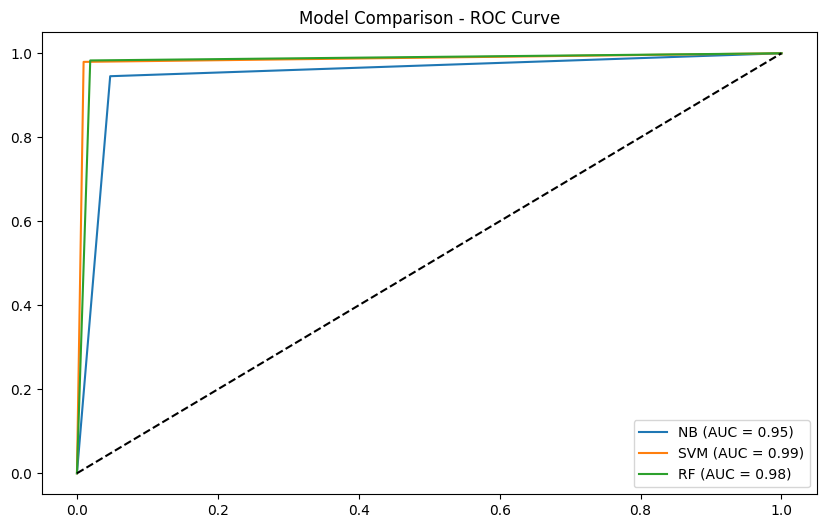

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Example: Plotting ROC Curves for all three
plt.figure(figsize=(10,6))
for name, pred in [("NB", y_pred_nb), ("SVM", y_pred_svm), ("RF", y_pred_rf)]:
    fpr, tpr, _ = roc_curve(y_test, pred)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Model Comparison - ROC Curve')
plt.legend()
plt.show()